# EDA och Data Cleaning av Gym Dataset
**Projekt i Datakvalitet och RAG**
I denna notebook undersöker och preprocessar vi vårt dataset med gymövningar. Syftet är att säkerställa hög datakvalitet innan informationen skickas vidare till vår vektordatabas och LLM. Vi fokuserar på *kompletthet* (hantering av saknade värden) och *brusreducering* (borttagning av onödig data).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sätt en snygg stil på våra grafer
plt.style.use('ggplot')

#### 1. Läs in och utforska datan
Vi börjar med att läsa in originalfilen och titta på de första raderna samt datatyperna för att få en överblick.

In [ ]:
# Läs in datan från CSV-filen
df = pd.read_csv('megaGymDataset.csv')

# Visa grundläggande information
print("--- INFO OM DATAN ---")
df.info()

# Visa de 5 första raderna
df.head()

--- INFO OM DATAN ---
<class 'pandas.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2918 non-null   int64  
 1   Title       2918 non-null   str    
 2   Desc        1368 non-null   str    
 3   Type        2918 non-null   str    
 4   BodyPart    2918 non-null   str    
 5   Equipment   2886 non-null   str    
 6   Level       2918 non-null   str    
 7   Rating      1031 non-null   float64
 8   RatingDesc  862 non-null    str    
dtypes: float64(1), int64(1), str(7)
memory usage: 819.1 KB


,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


#### 2. Utforska saknade värden (Missing Values)
En kritisk del av datakvalitet är att identifiera hur komplett datan är. Vi visualiserar antalet saknade rader per kolumn för att fatta beslut om hur de ska hanteras.

--- SAKNADE VÄRDEN PER KOLUMN ---
Unnamed: 0       0
Title            0
Desc          1550
Type             0
BodyPart         0
Equipment       32
Level            0
Rating        1887
RatingDesc    2056
dtype: int64


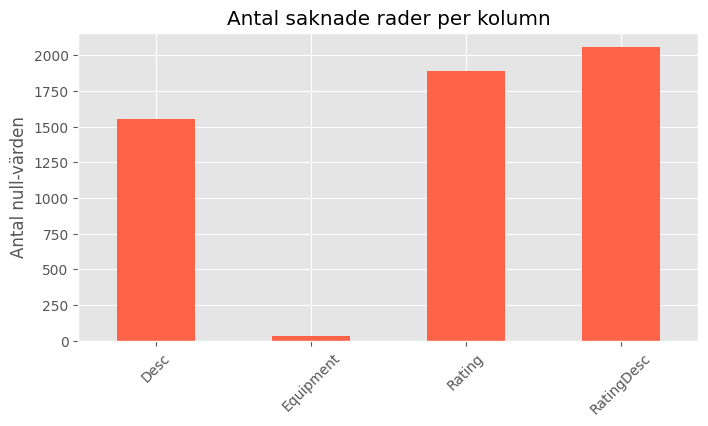

In [7]:
print("--- SAKNADE VÄRDEN PER KOLUMN ---")
missing_values = df.isnull().sum()
print(missing_values)

# Plotta de saknade värdena
missing_values[missing_values > 0].plot(kind='bar', color='tomato', figsize=(8, 4))
plt.title('Antal saknade rader per kolumn')
plt.ylabel('Antal null-värden')
plt.xticks(rotation=45)
plt.show()

#### 3. Beslut kring städning (Data Cleaning Strategy)
Utifrån vår EDA (Exploratory Data Analysis) fattar vi följande beslut för att optimera datan för RAG-systemet:
1. **Rating & RatingDesc** saknar en enorm mängd värden. Eftersom vår RAG-modell ska fokusera på instruktioner, väljer vi att ta bort (droppa) dessa kolumner helt för att minska brus.
2. **Desc (Beskrivning)** är kärnan i vår RAG. Rader som saknar beskrivning är värdelösa för vår LLM, så dessa rader tas bort (dropna).
3. **Equipment.** Om utrustning saknas beror det med stor sannolikhet på att övningen utförs med kroppsvikt. Vi fyller i (imputerar) dessa med "Body Only" istället för att kasta raderna.
4. **Text-tvätt.** Vi rensar bort dolda radbrytningar i texten så att LangChains "text splitters" fungerar felfritt senare.

In [8]:
# Skapa en kopia för städning
df_clean = df.copy()

# 1. Ta bort onödiga/trasiga kolumner
df_clean = df_clean.drop(columns=['Rating', 'RatingDesc', 'Unnamed: 0'], errors='ignore')

# 2. Ta bort rader där instruktionen (Desc) saknas
df_clean = df_clean.dropna(subset=['Desc'])

# 3. Fyll i saknad utrustning med "Body Only"
if 'Equipment' in df_clean.columns:
    df_clean['Equipment'] = df_clean['Equipment'].fillna('Body Only')

# 4. Tvätta instruktionstexten (tar bort \n och \r)
df_clean['Desc'] = df_clean['Desc'].str.replace('\n', ' ').str.replace('\r', '').str.strip()

#### 4. Hantering av dubbletter och avvikelser (Outliers)
För att förhindra att AI-modellen blir förvirrad eller ger repetitiva svar måste vi säkerställa att varje övning bara finns med en gång i databasen. Vi kontrollerar också att kategorierna för utrustning ser rimliga ut.

In [9]:
# Visa unika värden för utrustning för att se att inget ser uppenbart fel ut
print("--- UNIKA KATEGORIER FÖR UTRUSTNING ---")
print(df_clean['Equipment'].unique())

# Ta bort eventuella dubbletter baserat på övningens titel
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Title'], keep='first')
dropped_duplicates = initial_rows - len(df_clean)

print(f"\nAntal borttagna dubbletter: {dropped_duplicates}")

# Återställ index
df_clean = df_clean.reset_index(drop=True)

--- UNIKA KATEGORIER FÖR UTRUSTNING ---
<ArrowStringArray>
[        'Bands',       'Barbell',   'Kettlebells',      'Dumbbell',
         'Other',         'Cable',       'Machine',     'Body Only',
 'Medicine Ball', 'Exercise Ball',     'Foam Roll',  'E-Z Curl Bar']
Length: 12, dtype: str

Antal borttagna dubbletter: 9


#### 5. Resultat och Export
Nu verifierar vi att all data är komplett och exporterar den tvättade filen. Denna nya CSV-fil är nu av hög datakvalitet och redo att laddas in i vår RAG-applikation.

In [10]:
print("--- RESULTAT EFTER STÄDNING ---")
print(f"Ursprungligt antal rader: {len(df)}")
print(f"Nytt antal rader: {len(df_clean)}")
print("\nÅterstående saknade värden:")
print(df_clean.isnull().sum())

# Exportera filen
output_file = 'megaGymDataset_ready.csv'
df_clean.to_csv(output_file, index=False)
print(f"\n✅ Städningen är klar! Filen är sparad som: {output_file}")

--- RESULTAT EFTER STÄDNING ---
Ursprungligt antal rader: 2918
Nytt antal rader: 1359

Återstående saknade värden:
Title        0
Desc         0
Type         0
BodyPart     0
Equipment    0
Level        0
dtype: int64

✅ Städningen är klar! Filen är sparad som: megaGymDataset_ready.csv
